#### Make Model w/ Larger Dataset

In [13]:
# Lib's Dependencies

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
import pandas as pd

In [14]:
insuranceDf = pd.read_csv(r"https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/refs/heads/master/insurance.csv")
insuranceDf.head(), insuranceDf.dtypes, insuranceDf.shape

(   age     sex     bmi  children smoker     region      charges
 0   19  female  27.900         0    yes  southwest  16884.92400
 1   18    male  33.770         1     no  southeast   1725.55230
 2   28    male  33.000         3     no  southeast   4449.46200
 3   33    male  22.705         0     no  northwest  21984.47061
 4   32    male  28.880         0     no  northwest   3866.85520,
 age           int64
 sex          object
 bmi         float64
 children      int64
 smoker       object
 region       object
 charges     float64
 dtype: object,
 (1338, 7))

In [15]:
# One Hot Encode Pandas
insuranceDf_encoded = pd.get_dummies(insuranceDf)
insuranceDf_encoded.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


##### Data Splitting

In [16]:
# Create Target & Feature

y = insuranceDf_encoded["charges"]
X = insuranceDf_encoded[["age", "bmi", "children", "sex_female", "sex_male", "smoker_no", "smoker_yes",
                         "region_northeast", "region_northwest", "region_southeast", "region_southwest"]]

In [17]:
import sklearn
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

##### Model Create & Eval 

Model 1

In [18]:
tf.random.set_seed(42)

model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(3),
    tf.keras.layers.Dense(1)
])

model_1.compile(loss=keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                metrics=["mae"])

model_1.fit(X_train, y_train, epochs=300, verbose=2)

Epoch 1/300
34/34 - 1s - 27ms/step - loss: 13319.8252 - mae: 13319.8252
Epoch 2/300
34/34 - 0s - 2ms/step - loss: 13220.3867 - mae: 13220.3867
Epoch 3/300
34/34 - 0s - 2ms/step - loss: 13018.2100 - mae: 13018.2100
Epoch 4/300
34/34 - 0s - 2ms/step - loss: 12680.6924 - mae: 12680.6924
Epoch 5/300
34/34 - 0s - 2ms/step - loss: 12198.4590 - mae: 12198.4590
Epoch 6/300
34/34 - 0s - 2ms/step - loss: 11575.9551 - mae: 11575.9551
Epoch 7/300
34/34 - 0s - 2ms/step - loss: 10845.4932 - mae: 10845.4932
Epoch 8/300
34/34 - 0s - 2ms/step - loss: 10090.9395 - mae: 10090.9395
Epoch 9/300
34/34 - 0s - 2ms/step - loss: 9366.4180 - mae: 9366.4180
Epoch 10/300
34/34 - 0s - 2ms/step - loss: 8711.2051 - mae: 8711.2051
Epoch 11/300
34/34 - 0s - 2ms/step - loss: 8185.0962 - mae: 8185.0962
Epoch 12/300
34/34 - 0s - 3ms/step - loss: 7810.6953 - mae: 7810.6953
Epoch 13/300
34/34 - 0s - 2ms/step - loss: 7595.4668 - mae: 7595.4668
Epoch 14/300
34/34 - 0s - 2ms/step - loss: 7498.5273 - mae: 7498.5273
Epoch 15/300

In [19]:
model_1.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3679.3115 - mae: 3679.3115  


[3606.9208984375, 3606.9208984375]

In [20]:
y_train.median(), y_train.mean()

(np.float64(9575.4421), np.float64(13346.089736364485))

Model 2

In [21]:
tf.random.set_seed(42)

model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(5),
    tf.keras.layers.Dense(1)
])

model_2.compile(loss=keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                metrics=["mae"])

history = model_2.fit(X_train, y_train, epochs=200, verbose=2)

Epoch 1/200
34/34 - 1s - 30ms/step - loss: 13175.5225 - mae: 13175.5225
Epoch 2/200
34/34 - 0s - 3ms/step - loss: 11625.8467 - mae: 11625.8467
Epoch 3/200
34/34 - 0s - 2ms/step - loss: 8037.4385 - mae: 8037.4385
Epoch 4/200
34/34 - 0s - 2ms/step - loss: 7426.5352 - mae: 7426.5352
Epoch 5/200
34/34 - 0s - 3ms/step - loss: 7349.3799 - mae: 7349.3799
Epoch 6/200
34/34 - 0s - 3ms/step - loss: 7283.2778 - mae: 7283.2778
Epoch 7/200
34/34 - 0s - 2ms/step - loss: 7207.4404 - mae: 7207.4404
Epoch 8/200
34/34 - 0s - 3ms/step - loss: 7123.8843 - mae: 7123.8843
Epoch 9/200
34/34 - 0s - 3ms/step - loss: 7029.2402 - mae: 7029.2402
Epoch 10/200
34/34 - 0s - 3ms/step - loss: 6918.2305 - mae: 6918.2305
Epoch 11/200
34/34 - 0s - 3ms/step - loss: 6783.3452 - mae: 6783.3452
Epoch 12/200
34/34 - 0s - 2ms/step - loss: 6626.7637 - mae: 6626.7637
Epoch 13/200
34/34 - 0s - 2ms/step - loss: 6494.8745 - mae: 6494.8745
Epoch 14/200
34/34 - 0s - 2ms/step - loss: 6422.2090 - mae: 6422.2090
Epoch 15/200
34/34 - 0s 

In [22]:
model_2.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3238.7637 - mae: 3238.7637  


[3187.18505859375, 3187.18505859375]

In [23]:
model_1.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3679.3115 - mae: 3679.3115 


[3606.9208984375, 3606.9208984375]

Text(0.5, 0, 'epochs')

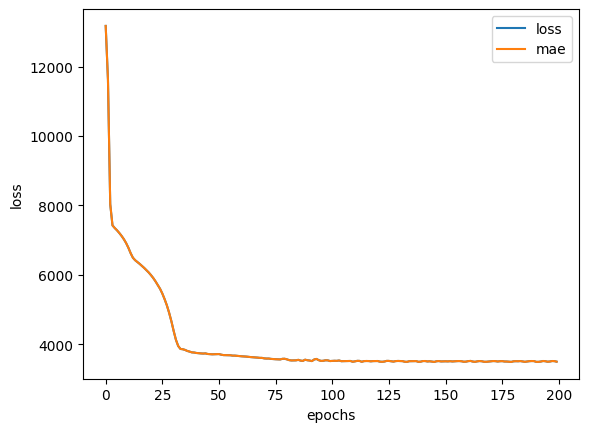

In [24]:
pd.DataFrame(history.history).plot()
plt.ylabel("loss")
plt.xlabel("epochs")

##### Preprocessing Data (Normalization & Standarization)

Steps in Modelling w/ Tensorflow
1. Turn all data into numbers (Neural network can't handle string)
2. Make sure all of your tensors are in the right shape
3. Scale features (Noramalize or standarize, neural network tend to prefer normalization)

In [34]:
# X.columns

In [33]:
# X["age"].plot(kind="hist")

In [32]:
# X["bmi"].plot(kind="hist")

In [37]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

insuranceDf2 = pd.read_csv(r"https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/refs/heads/master/insurance.csv")
insuranceDf2.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [41]:
# Create column transformer
ct = make_column_transformer(
    (MinMaxScaler(), ["age", "bmi", "children"]), #Turn all values in theese columns between 1 & 0
    (OneHotEncoder(handle_unknown="ignore"),["sex", "smoker", "region"])
)

# Create X & y
X = insuranceDf2.drop("charges" ,axis=1)
y = insuranceDf2["charges"]

# Train Test Splitting
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit
ct.fit(X_train2)

# Transform training and test w/ normalization (MMX) and OneHotEncoder
X_train2_normal = ct.transform(X_train2)
X_test2_normal = ct.transform(X_test2) 


In [43]:
# New look
X_train2.loc[0]

age                19
sex            female
bmi              27.9
children            0
smoker            yes
region      southwest
Name: 0, dtype: object

In [46]:
X_train2_normal[0]

array([0.60869565, 0.10734463, 0.4       , 1.        , 0.        ,
       1.        , 0.        , 0.        , 1.        , 0.        ,
       0.        ])

In [48]:
X_train2.shape, X_train2_normal.shape

((1070, 6), (1070, 11))

In [66]:
# Build a neural network
model_A = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(5),
    tf.keras.layers.Dense(1)
])

model_A.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                metrics=["mae"])

history2 = model_A.fit(X_train2_normal, y_train2, epochs=200, verbose=2)

Epoch 1/200
34/34 - 1s - 32ms/step - loss: 13335.8008 - mae: 13335.8008
Epoch 2/200
34/34 - 0s - 3ms/step - loss: 13218.7666 - mae: 13218.7666
Epoch 3/200
34/34 - 0s - 3ms/step - loss: 12711.3926 - mae: 12711.3926
Epoch 4/200
34/34 - 0s - 3ms/step - loss: 11403.4385 - mae: 11403.4385
Epoch 5/200
34/34 - 0s - 3ms/step - loss: 9574.9336 - mae: 9574.9336
Epoch 6/200
34/34 - 0s - 2ms/step - loss: 8264.8428 - mae: 8264.8428
Epoch 7/200
34/34 - 0s - 3ms/step - loss: 7853.3242 - mae: 7853.3242
Epoch 8/200
34/34 - 0s - 2ms/step - loss: 7690.5435 - mae: 7690.5435
Epoch 9/200
34/34 - 0s - 3ms/step - loss: 7531.7393 - mae: 7531.7393
Epoch 10/200
34/34 - 0s - 3ms/step - loss: 7365.5967 - mae: 7365.5967
Epoch 11/200
34/34 - 0s - 3ms/step - loss: 7183.9409 - mae: 7183.9409
Epoch 12/200
34/34 - 0s - 3ms/step - loss: 6982.0127 - mae: 6982.0127
Epoch 13/200
34/34 - 0s - 3ms/step - loss: 6751.0186 - mae: 6751.0186
Epoch 14/200
34/34 - 0s - 4ms/step - loss: 6483.4492 - mae: 6483.4492
Epoch 15/200
34/34 -

In [67]:
model_A.evaluate(X_test2_normal, y_test2)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3212.5505 - mae: 3212.5505  


[3158.6298828125, 3158.6298828125]

Text(0.5, 0, 'epochs')

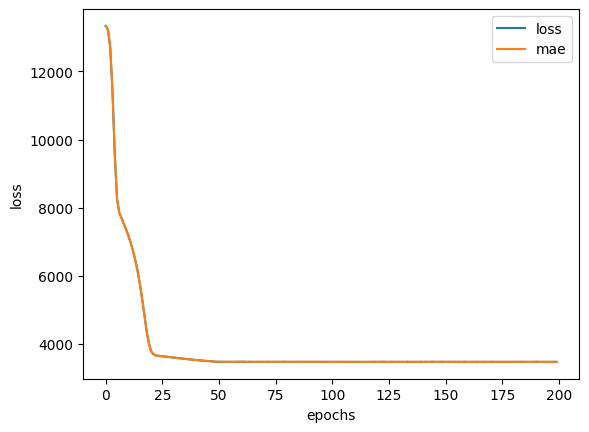

In [68]:
pd.DataFrame(history2.history).plot()
plt.ylabel("loss")
plt.xlabel("epochs")